In [48]:

import numpy as np
import pandas as pd
import os
from mplsoccer import Pitch
import tqdm

In [2]:
pass_df = pd.read_csv('./statsbomb360 data/preprocess_pass_data',index_col=0)

In [3]:
pass_df

,type_name,type,pass_type,result_name,pass_outcome,freeze_frame,location,pass_end_location,pass_angle,pass_length,player_id_x,player_name
0,pass,Pass,Recovery,fail,Incomplete,"[{'teammate': True, 'actor': False, 'keeper': ...","[43.8, 52.2]","[43.2, 52.2]",3.141593,0.600000,10167.0,Tatiana Pinto
1,pass,Pass,Recovery,fail,Incomplete,"[{'teammate': True, 'actor': False, 'keeper': ...","[76.9, 27.9]","[71.8, 30.7]",2.639502,5.818075,26093.0,Gun Nathalie Björn
2,pass,Pass,NaN,success,NaN,"[{'teammate': True, 'actor': True, 'keeper': F...","[34.1, 51.2]","[20.1, 39.1]",-2.428863,18.504324,32143.0,Diana Gomes
3,pass,Pass,NaN,fail,Incomplete,"[{'teammate': True, 'actor': True, 'keeper': T...","[22.9, 34.8]","[35.1, 13.0]",-1.060587,24.981594,10145.0,Patricia Sousa
4,pass,Pass,NaN,success,NaN,"[{'teammate': True, 'actor': False, 'keeper': ...","[108.6, 35.8]","[110.0, 47.9]",1.455606,12.180722,10215.0,Fridolina Rolfö
...,...,...,...,...,...,...,...,...,...,...,...,...
114549,pass,Pass,Recovery,success,NaN,"[{'teammate': True, 'actor': False, 'keeper': ...","[30.2, 61.8]","[49.9, 57.9]",-0.195442,20.082330,31900.0,Oleksandr Karavaev
114550,pass,Pass,NaN,success,NaN,"[{'teammate': True, 'actor': False, 'keeper': ...","[49.9, 57.9]","[54.8, 44.3]",-1.224980,14.455794,16509.0,Viktor Tsygankov
114551,pass,Pass,NaN,fail,Incomplete,"[{'teammate': True, 'actor': False, 'keeper': ...","[54.8, 44.3]","[43.4, 41.3]",-2.884269,11.788130,18881.0,Artem Besedin
114552,pass,Pass,Recovery,success,NaN,"[{'teammate': False, 'actor': False, 'keeper':...","[76.7, 38.8]","[84.7, 54.7]",1.104636,17.799158,30322.0,Darko Churlinov


- pass_end_location은 기존 리스트형식이었지만, pd.read_csv는 모든 데이터를 문자열 형식으로 불러오므로 다시 리스트 형식으로 변환해야함

In [8]:
print("pass_end_location type : ",type(pass_df['pass_end_location'][0]))
pass_df['pass_end_location'][0]

pass_end_location type :  <class 'str'>


'[43.2, 52.2]'

In [9]:
import ast
pass_df['pass_end_location'] = pass_df['pass_end_location'].apply(ast.literal_eval)

In [10]:
print("pass_end_location type : ",type(pass_df['pass_end_location'][0]))
pass_df['pass_end_location'][0]

pass_end_location type :  <class 'list'>


[43.2, 52.2]

- 하나의 pixel에 패스한 경우로이므로 하나의 pixel만 1, 나머지는 0으로 labeling처리함

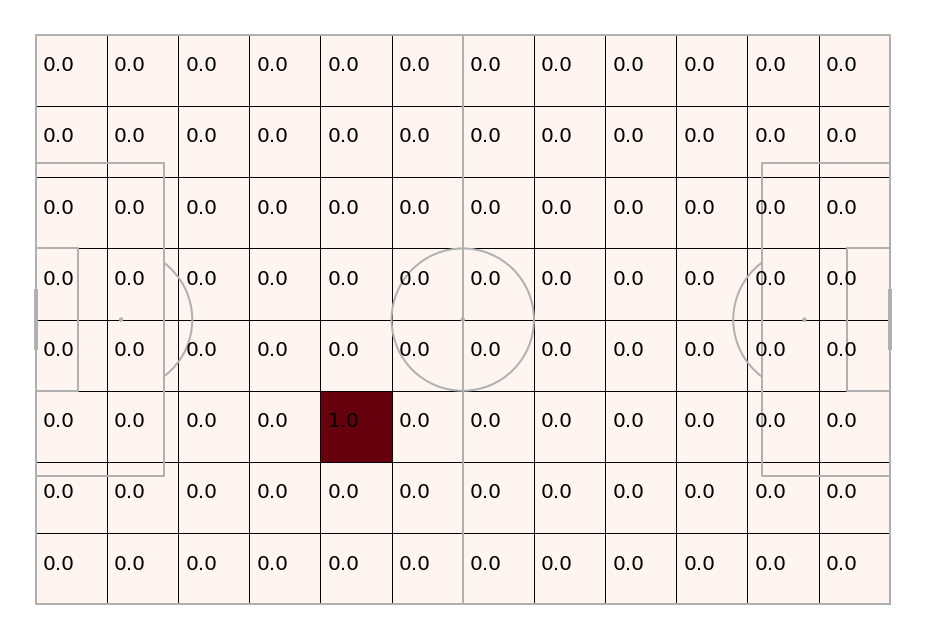

In [47]:
pitch = Pitch(line_zorder=2)
fig, ax = pitch.draw(figsize=(18,9))

bin_statistic = pitch.bin_statistic(pass_df['pass_end_location'][0][0], 
                                    pass_df['pass_end_location'][0][1], bins=(12, 8))

pitch.heatmap(bin_statistic, ax=ax, cmap='Reds', edgecolor='black')

for i in range(8):
    for j in range(12):
        ax.text(x=bin_statistic['cx'][i][j]-4,
                y=bin_statistic['cy'][i][j],
                #각 pixel 첫 위치에 messi패스 횟수
                s=bin_statistic['statistic'][i][j],fontsize=20)

- 104x68에서 하나의 값만 1이 되도록 라벨링

In [33]:
pitch = Pitch(line_zorder=2, pitch_color='#f4edf0')
Pass_labeling_matrix = np.zeros((len(pass_df), 68, 104))
    
for i in tqdm.tqdm(range(len(pass_df))):
    x, y = pass_df.loc[i,'pass_end_location']
    Pass_labeling_matrix[i] = pitch.bin_statistic(x, y, bins=(104, 68))['statistic']

100%|██████████| 114554/114554 [00:48<00:00, 2363.10it/s]


In [35]:
Pass_labeling_matrix.shape

(114554, 68, 104)

- pass labeling matrix 저장하기

In [49]:
# 저장할 디렉토리 생성
directory = 'Label Matrix/Pass label Sparse Matrix'
os.makedirs(directory, exist_ok=True)

# 각각의 데이터를 파일로 저장
for i in tqdm.tqdm(range(len(Pass_labeling_matrix))):
    filename = os.path.join(directory, f'Pass_labeling_{i}.txt')
    with open(filename, 'w') as file:
        np.savetxt(file, Pass_labeling_matrix[i], delimiter=',')

100%|██████████| 114554/114554 [05:39<00:00, 337.23it/s]
